In [1]:
# # Phase 3: grid-based differentiable longitudinal tomography
#
# This VS Code-friendly Julia notebook reconstructs an unknown initial
# longitudinal phase-space density from a synthetic RWCM cascade. The unknown
# density is represented by nonnegative masses on fixed cells inside the
# stationary single-RF separatrix.
#
# The first demonstration deliberately uses the same grid for the target and
# reconstruction. This is the cleanest end-to-end sanity check. A later test
# should generate targets from particles or a finer grid to avoid an inverse
# crime.

In [2]:
import Pkg

Pkg.activate(normpath(joinpath(@__DIR__, "..")))

using LongitudinalTomography

println(
    "soft_assignments loaded: ",
    isdefined(LongitudinalTomography, :soft_assignments),
)

println(
    "build_response_matrix loaded: ",
    isdefined(LongitudinalTomography, :build_response_matrix),
)

  Activating project at `~/Desktop/longitudinal_dynamics`


soft_assignments loaded: true
build_response_matrix loaded: true


In [3]:
using LongitudinalTomography
using CairoMakie
using Printf

CairoMakie.activate!()

In [4]:
const PROTON_MASS_EV = 938.2720813e6

kinetic_energy_eV = 8.0e9
total_energy_eV = kinetic_energy_eV + PROTON_MASS_EV
gamma_s = total_energy_eV / PROTON_MASS_EV
beta_s = sqrt(1 - 1 / gamma_s^2)

machine = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=beta_s,
    E_s_eV=total_energy_eV,
    rf_kick_eV=60.0e3,
    phi_s=0.0,
    delta_t_s=0.0,
)

@printf("Q_s                  = %.7f\n", synchrotron_tune(machine))
@printf("synchrotron period   = %.2f turns\n", synchrotron_period_turns(machine))


Q_s                  = 0.0023643
synchrotron period   = 422.97 turns


In [5]:
# ## Observation grid and soft RWCM bins
#
# The 0--250-turn span covers approximately half a small-amplitude synchrotron
# period for these Recycler-like parameters. Complete turns are held out from
# training so that validation tests dynamical prediction rather than randomly
# hidden waveform pixels.

turns = collect(0.0:5.0:250.0)

half_width_s = bucket_half_width_s(machine)
n_time_bins = 75
time_bin_centers_s = collect(range(
    machine.delta_t_s - half_width_s,
    machine.delta_t_s + half_width_s;
    length=n_time_bins,
))
time_bin_spacing_s = time_bin_centers_s[2] - time_bin_centers_s[1]
soft_sigma_s = 0.75 * time_bin_spacing_s

validation_turn_indices = collect(5:5:length(turns))
training_turn_indices = setdiff(
    collect(eachindex(turns)),
    validation_turn_indices,
)

@printf("bucket half-width      = %.3f ns\n", bucket_half_width_s(machine) * 1e9)
@printf("profiles              = %d\n", length(turns))
@printf("training profiles     = %d\n", length(training_turn_indices))
@printf("validation profiles   = %d\n", length(validation_turn_indices))
@printf("time bins             = %d\n", n_time_bins)

bucket half-width      = 9.469 ns
profiles              = 51
training profiles     = 41
validation profiles   = 10
time bins             = 75


In [6]:
# ## Grid cells inside the separatrix
#
# Cell centers are used instead of grid edges. `energy_margin` keeps the active
# cells away from the elliptic `k -> 1` limit at the separatrix.

grid = separatrix_grid(
    n_theta=51,
    n_P=51,
    energy_margin=2e-3,
)

@assert all(inside_separatrix(
    grid.theta_nodes,
    grid.P_nodes;
    margin=grid.energy_margin,
))

@printf("active grid cells     = %d\n", length(grid))
@printf("TV neighbor pairs     = %d\n", length(grid.edge_from))

active grid cells     = 1647
TV neighbor pairs     = 3194


In [7]:
# ## Precompute the tomographic response matrix
#
# If `w` contains the initial cell masses, the complete predicted cascade is
#
#     y_hat = A*w
#
# followed only by a reshape. Exact elliptic transport is therefore evaluated
# once rather than at every optimization step.

response = build_response_matrix(
    grid,
    turns,
    machine,
    time_bin_centers_s;
    sigma=soft_sigma_s,
)

response_megabytes = Base.summarysize(response.matrix) / 1024^2

@printf(
    "response dimensions   = %d x %d\n",
    size(response.matrix, 1),
    size(response.matrix, 2),
)
@printf("response memory       = %.1f MiB\n", response_megabytes)

# Every response column deposits unit charge at every turn.
response_tensor = reshape(
    response.matrix,
    length(turns),
    n_time_bins,
    length(grid),
)
response_charge_error = maximum(abs.(
    sum(response_tensor; dims=2) .- 1,
))
@printf("response charge error = %.3e\n", response_charge_error)

response dimensions   = 3825 x 1647
response memory       = 48.1 MiB
response charge error = 6.661e-16


In [8]:
# ## Synthetic ground-truth distribution
#
# The target is a smooth, asymmetric two-component distribution. It is not
# assumed to be Gaussian by the reconstruction: every active grid-cell mass is
# independently adjustable through a softmax parameterization.

theta_nodes = grid.theta_nodes
P_nodes = grid.P_nodes

component_1 = exp.(-0.5 .* (
    ((theta_nodes .+ 0.42) ./ 0.34).^2 .+
    ((P_nodes .- 0.24) ./ 0.27).^2
))
component_2 = exp.(-0.5 .* (
    ((theta_nodes .- 0.55) ./ 0.24).^2 .+
    ((P_nodes .+ 0.28) ./ 0.20).^2
))

target_weights_unnormalized = 0.68 .* component_1 .+ 0.32 .* component_2
target_weights = target_weights_unnormalized ./ sum(target_weights_unnormalized)
target_profiles = profiles_from_response(response, target_weights)

@printf("target charge         = %.12f\n", sum(target_weights))
@printf(
    "target profile error = %.3e\n",
    maximum(abs.(sum(target_profiles; dims=2) .- 1)),
)

target charge         = 1.000000000000
target profile error = 6.661e-16


In [9]:
# ## Reconstruct the unknown cell masses
#
# The initial logits are zero, corresponding to a uniform density over active
# cells. The fit uses only the training turns. The regularizers are deliberately
# weak so that the profile data dominate this first demonstration.

initial_logits = zeros(length(grid))
initial_profiles = profiles_from_response(
    response,
    grid_weights_from_logits(initial_logits);
    normalize=false,
)
initial_training_mse = profile_mse(
    initial_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)

result = reconstruct_grid(
    response,
    target_profiles;
    iterations=2000,
    learning_rate=0.08,
    initial_logits=initial_logits,
    train_turn_indices=training_turn_indices,
    lambda_tv=1e-2,
    lambda_entropy=1e-6,
)

reconstructed_weights = result.weights
reconstructed_profiles = result.profiles

final_training_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)
validation_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=validation_turn_indices,
)
phase_space_l1 = sum(abs.(reconstructed_weights .- target_weights))

@printf("initial training MSE  = %.6e\n", initial_training_mse)
@printf("final training MSE    = %.6e\n", final_training_mse)
@printf("held-out-turn MSE     = %.6e\n", validation_mse)
@printf("phase-space L1 error  = %.6e\n", phase_space_l1)
@printf("reconstructed charge = %.12f\n", sum(reconstructed_weights))

initial training MSE  = 4.697752e-04
final training MSE    = 6.208217e-08
held-out-turn MSE     = 6.296875e-08
phase-space L1 error  = 5.612783e-02
reconstructed charge = 1.000000000000


In [10]:
# ## Initial phase-space reconstruction in physical coordinates

function physical_grid_plot_data(grid, weights, machine)
    weight_matrix = grid_weight_matrix(grid, weights)
    delta_t_axis_ns = delta_t_from_theta(grid.theta_axis, machine) .* 1e9
    delta_E_axis_MeV = delta_energy_from_P(grid.P_axis, machine) .* 1e-6

    # eta0 < 0 makes Delta E decrease with normalized P. Sort the physical
    # energy axis before plotting and reorder the corresponding matrix rows.
    energy_order = sortperm(delta_E_axis_MeV)
    plot_matrix = permutedims(weight_matrix[energy_order, :])
    return delta_t_axis_ns, delta_E_axis_MeV[energy_order], plot_matrix
end

target_dt_ns, target_dE_MeV, target_matrix = physical_grid_plot_data(
    grid,
    target_weights,
    machine,
)
reconstructed_dt_ns, reconstructed_dE_MeV, reconstructed_matrix =
    physical_grid_plot_data(grid, reconstructed_weights, machine)
difference_matrix = reconstructed_matrix .- target_matrix

theta_separatrix = range(-pi, pi; length=1000)
P_separatrix = 2 .* cos.(theta_separatrix ./ 2)
delta_t_separatrix_ns = delta_t_from_theta(theta_separatrix, machine) .* 1e9
delta_E_separatrix_upper_MeV = delta_energy_from_P(
    P_separatrix,
    machine,
) .* 1e-6
delta_E_separatrix_lower_MeV = delta_energy_from_P(
    -P_separatrix,
    machine,
) .* 1e-6

1000-element Vector{Float64}:
 4.946377487525266e-16
 0.025403296048253258
 0.050806340874036446
 0.07620888325736491
 0.10161067198322234
 0.12701145584404563
 0.1524109836422092
 0.17780900419251075
 0.20320526632464855
 0.22859951888571572
 ⋮
 0.20320526632464855
 0.17780900419250895
 0.1524109836422092
 0.12701145584404563
 0.10161067198322234
 0.07620888325736491
 0.050806340874036446
 0.025403296048253258
 4.946377487525266e-16

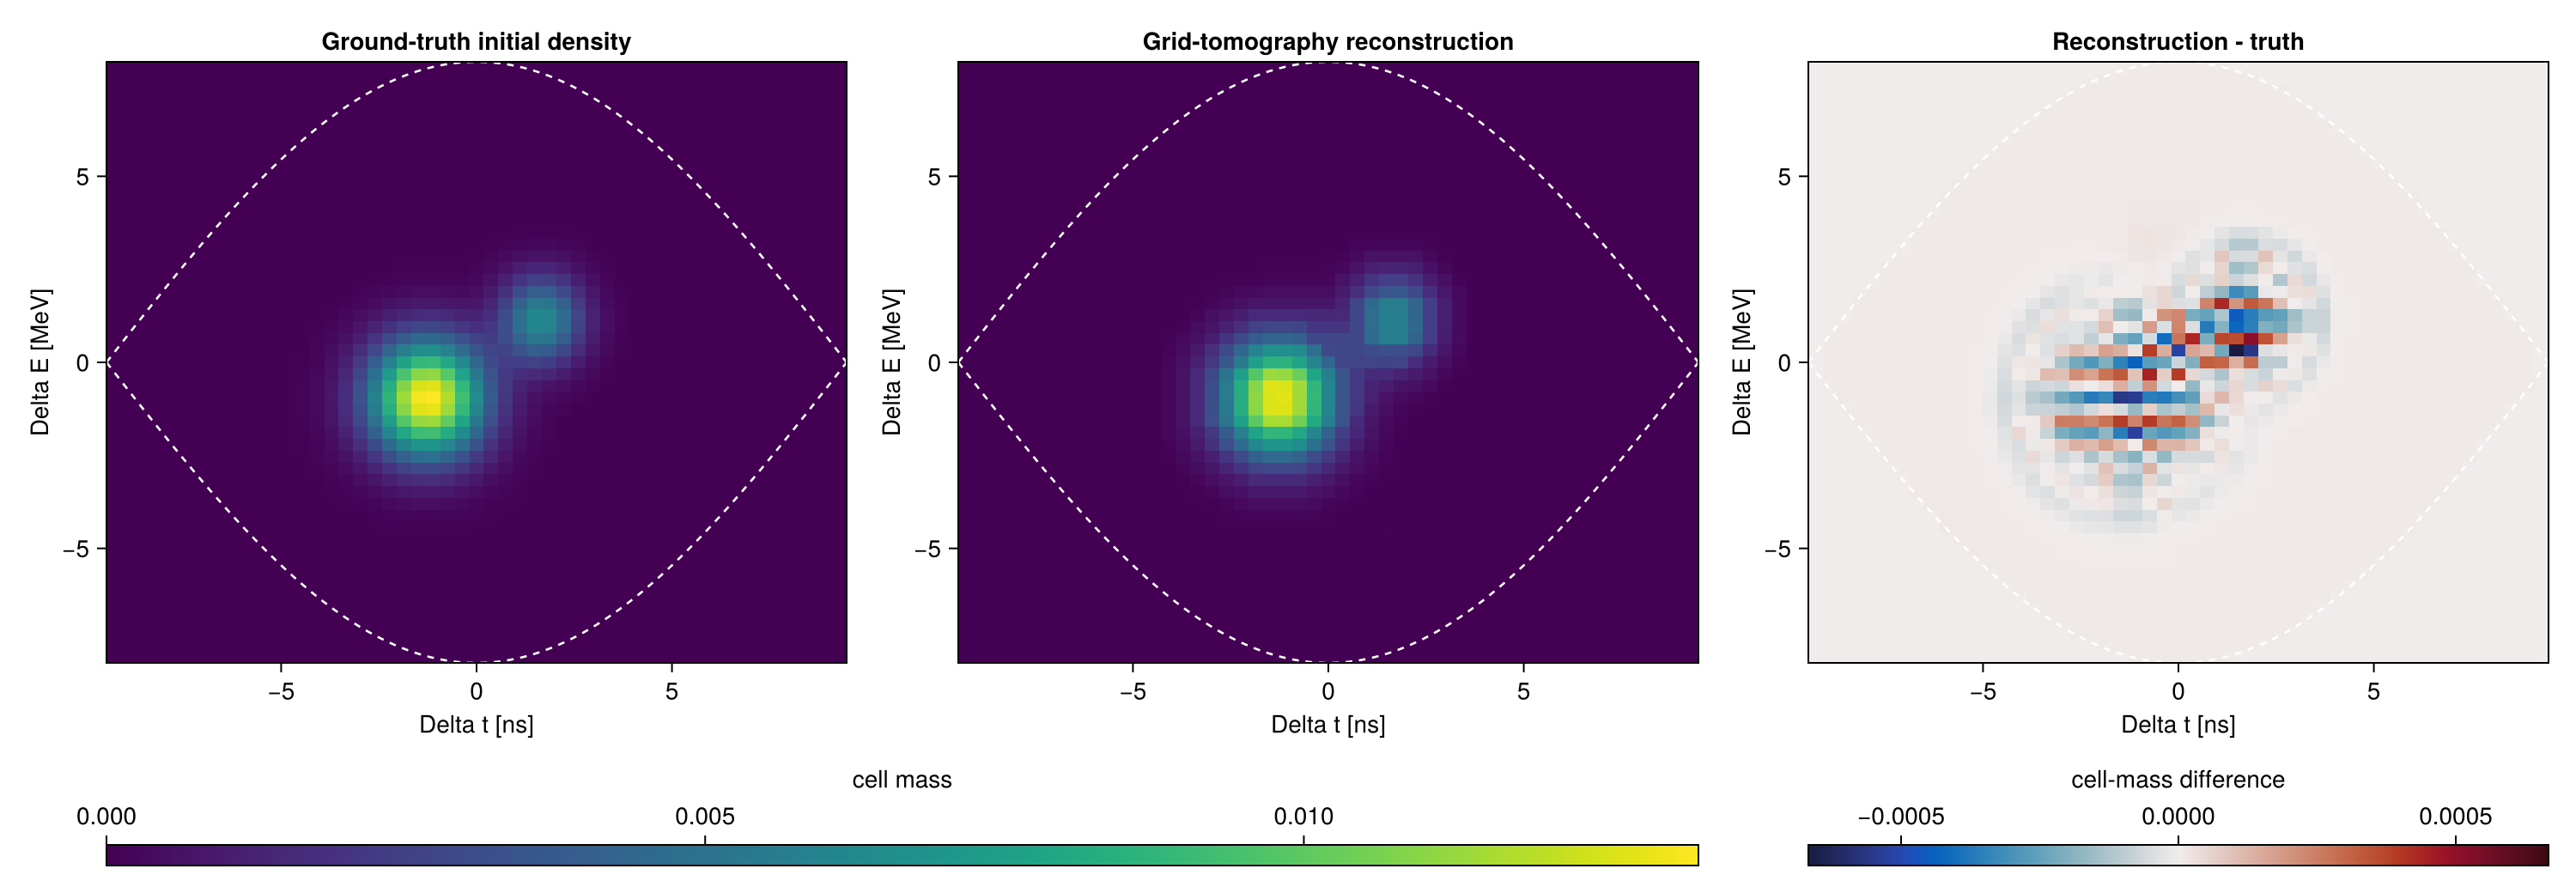

CairoMakie.Screen{IMAGE}


In [11]:
phase_figure = Figure(size=(1500, 520))
common_colorrange = (
    0.0,
    max(maximum(target_matrix), maximum(reconstructed_matrix)),
)
difference_limit = max(maximum(abs.(difference_matrix)), eps(Float64))

axis_target = Axis(
    phase_figure[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="Ground-truth initial density",
)
target_heatmap = heatmap!(
    axis_target,
    target_dt_ns,
    target_dE_MeV,
    target_matrix;
    colormap=:viridis,
    colorrange=common_colorrange,
)

axis_reconstruction = Axis(
    phase_figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="Grid-tomography reconstruction",
)
heatmap!(
    axis_reconstruction,
    reconstructed_dt_ns,
    reconstructed_dE_MeV,
    reconstructed_matrix;
    colormap=:viridis,
    colorrange=common_colorrange,
)

axis_difference = Axis(
    phase_figure[1, 3];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="Reconstruction - truth",
)
difference_heatmap = heatmap!(
    axis_difference,
    target_dt_ns,
    target_dE_MeV,
    difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

for axis in (axis_target, axis_reconstruction, axis_difference)
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_upper_MeV;
        color=:white,
        linestyle=:dash,
        linewidth=1.3,
    )
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_lower_MeV;
        color=:white,
        linestyle=:dash,
        linewidth=1.3,
    )
end

Colorbar(phase_figure[2, 1:2], target_heatmap; vertical=false, label="cell mass")
Colorbar(
    phase_figure[2, 3],
    difference_heatmap;
    vertical=false,
    label="cell-mass difference",
)

display(phase_figure)

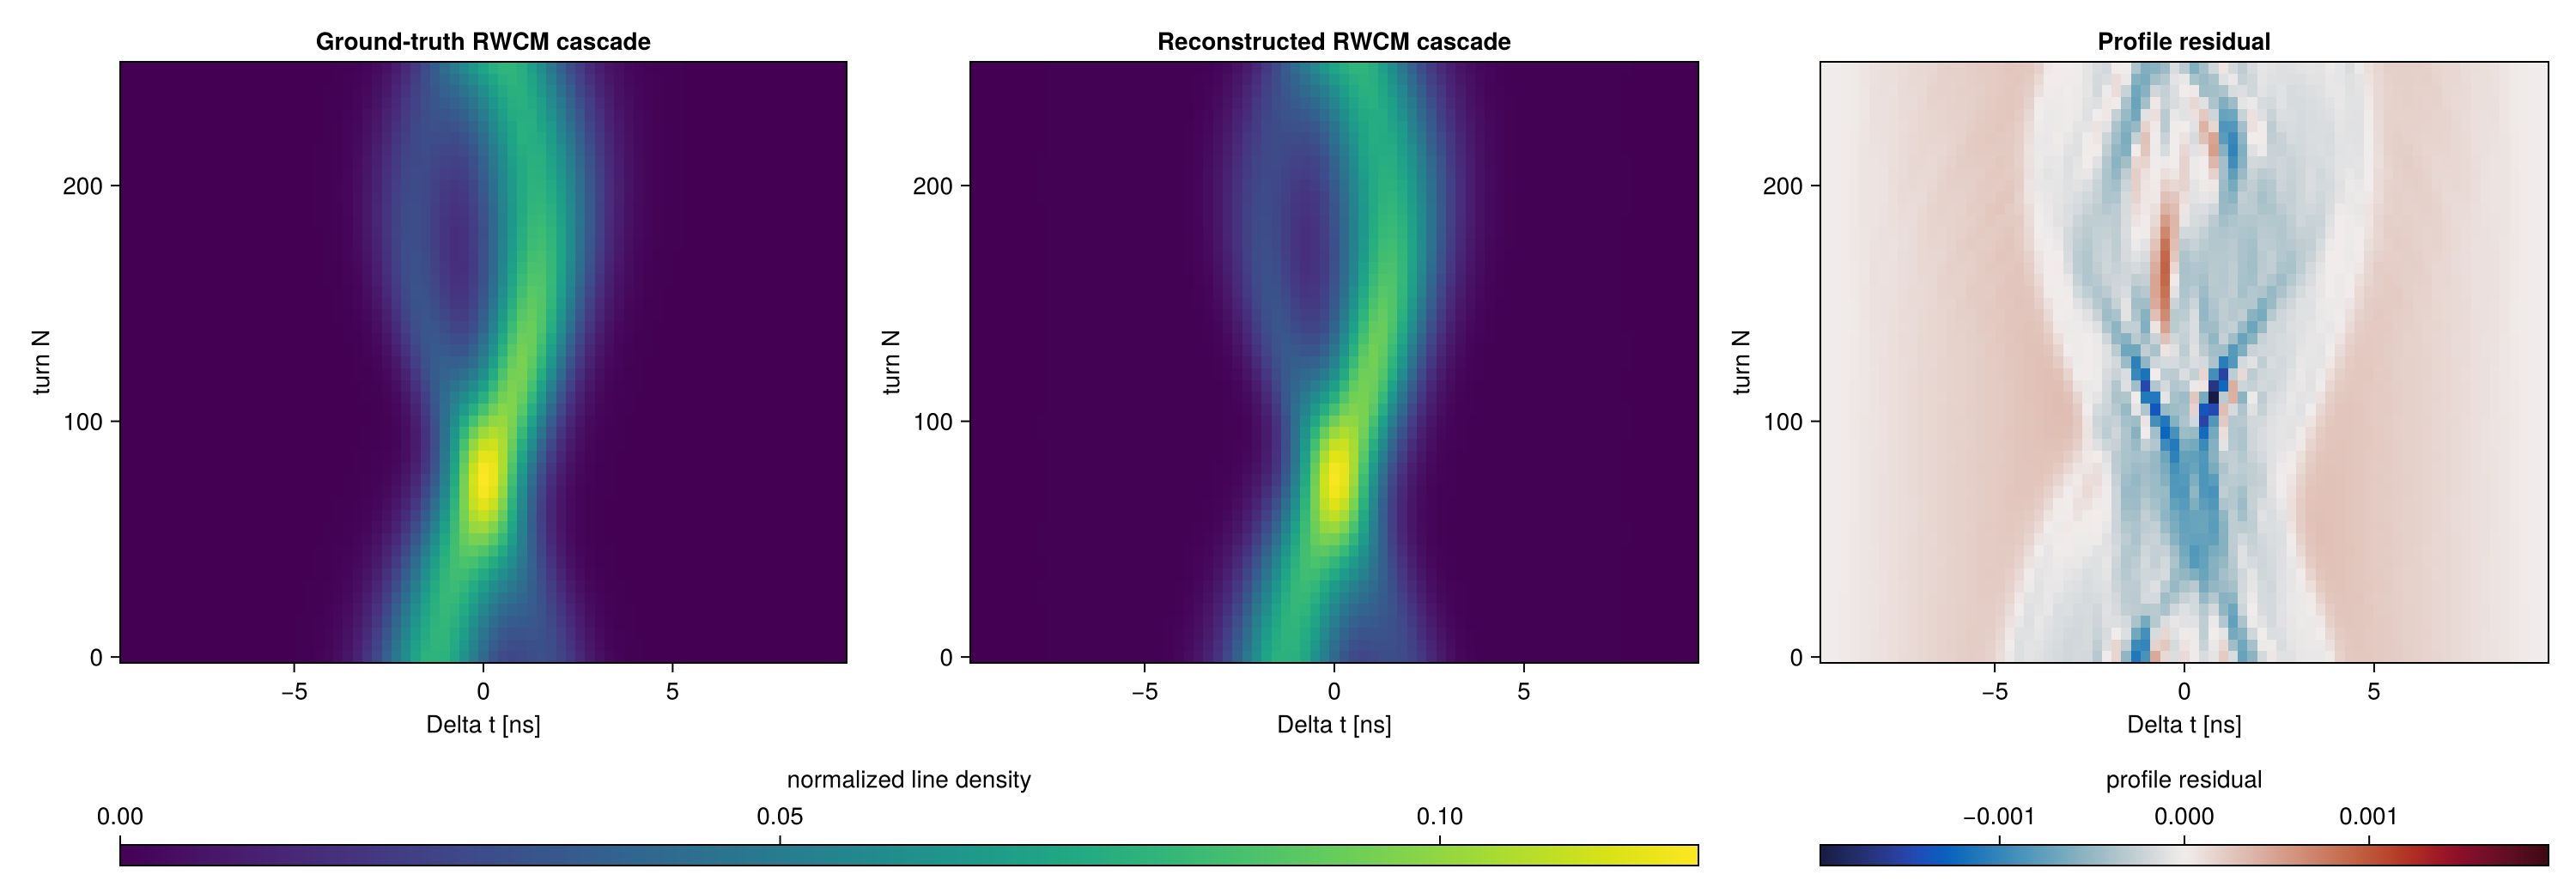

CairoMakie.Screen{IMAGE}


In [12]:
profile_residual = reconstructed_profiles .- target_profiles
profile_limit = max(maximum(target_profiles), maximum(reconstructed_profiles))
residual_limit = max(maximum(abs.(profile_residual)), eps(Float64))

cascade_figure = Figure(size=(1500, 520))

axis_target_cascade = Axis(
    cascade_figure[1, 1];
    xlabel="Delta t [ns]",
    ylabel="turn N",
    title="Ground-truth RWCM cascade",
)
target_cascade_heatmap = heatmap!(
    axis_target_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(target_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_reconstructed_cascade = Axis(
    cascade_figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="turn N",
    title="Reconstructed RWCM cascade",
)
heatmap!(
    axis_reconstructed_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(reconstructed_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_residual_cascade = Axis(
    cascade_figure[1, 3];
    xlabel="Delta t [ns]",
    ylabel="turn N",
    title="Profile residual",
)
residual_heatmap = heatmap!(
    axis_residual_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(profile_residual);
    colormap=:balance,
    colorrange=(-residual_limit, residual_limit),
)

Colorbar(
    cascade_figure[2, 1:2],
    target_cascade_heatmap;
    vertical=false,
    label="normalized line density",
)
Colorbar(
    cascade_figure[2, 3],
    residual_heatmap;
    vertical=false,
    label="profile residual",
)

display(cascade_figure)

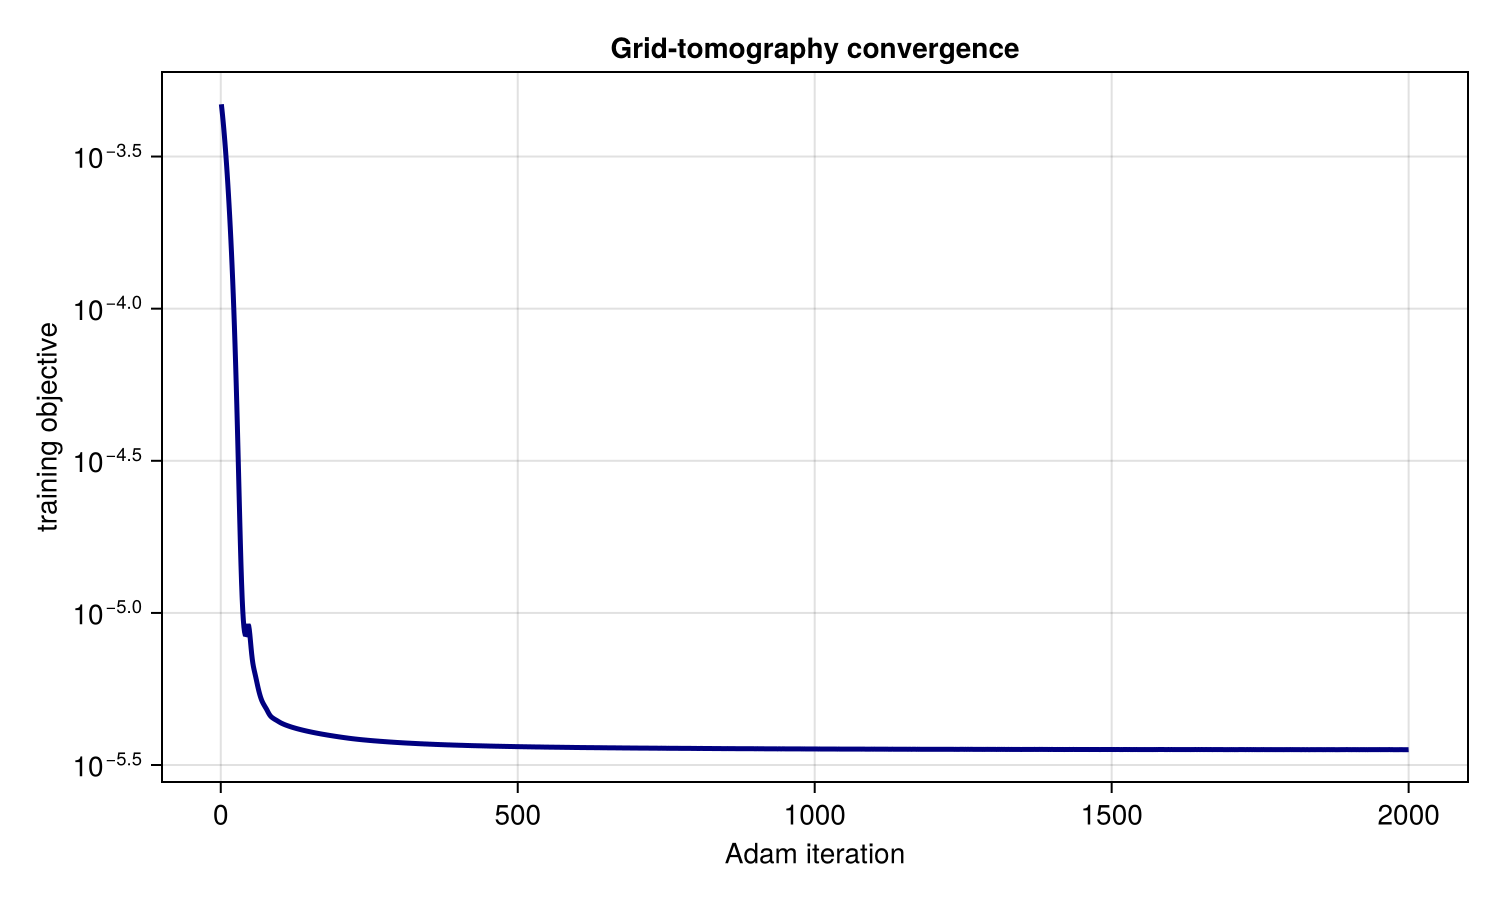

CairoMakie.Screen{IMAGE}


In [13]:
loss_figure = Figure(size=(750, 450))
loss_axis = Axis(
    loss_figure[1, 1];
    xlabel="Adam iteration",
    ylabel="training objective",
    yscale=log10,
    title="Grid-tomography convergence",
)
lines!(
    loss_axis,
    eachindex(result.loss_history),
    max.(result.loss_history, eps(Float64));
    color=:navy,
    linewidth=2.5,
)

display(loss_figure)